### 라이브러리 임포트 및 시각화 설정

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import time
import duckdb
import polars as pl
import os
import platform

# Polars, Pandas 출력 옵션 설정
pl.Config.set_tbl_rows(10)
pd.set_option('display.max_columns', 100)

# Mac 한글 폰트 설정 
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False


### 데이터 로드

In [10]:
BASE_DIR = os.path.abspath('..')
PARQUET_PATH = os.path.join(BASE_DIR, 'data', 'processed', 'sdot_master_2020_2026_geocoded.parquet')

print(f"데이터 경로: {PARQUET_PATH}")
print(f"파일 존재 여부: {os.path.exists(PARQUET_PATH)}\n")

# DuckDB에 Parquet 파일을 뷰(v_sdot)로 즉시 등록
# -> 메모리를 적게 차지하며, 이후 SQL 쿼리에서 'v_sdot' 테이블명으로 바로 호출 가능
duckdb.sql(f"CREATE OR REPLACE VIEW v_sdot AS SELECT * FROM read_parquet('{PARQUET_PATH}')")

query_check = """
    SELECT * 
    FROM v_sdot
    LIMIT 5
"""
display(duckdb.sql(query_check).pl())

데이터 경로: /Users/gomdori/Documents/Git/sdot-analysis/data/processed/sdot_master_2020_2026_geocoded.parquet
파일 존재 여부: True



measure_time,sensor_id,temp_max,temp_avg,temp_min,humi_max,humi_avg,humi_min,wind_spd_max,wind_spd_avg,wind_spd_min,wind_dir_max,wind_dir_avg,wind_dir_min,illu_max,illu_avg,illu_min,uv_max,uv_avg,uv_min,noise_max,noise_avg,noise_min,vibe_x_max_g,vibe_x_avg_g,vibe_x_min_g,vibe_y_max_g,vibe_y_avg_g,vibe_y_min_g,vibe_z_max_g,vibe_z_avg_g,vibe_z_min_g,vibe_x_max_mms,vibe_x_avg_mms,vibe_x_min_mms,vibe_y_max_mms,vibe_y_avg_mms,…,flag_vibe_z_min_g,flag_vibe_x_max_mms,flag_vibe_x_avg_mms,flag_vibe_x_min_mms,flag_vibe_y_max_mms,flag_vibe_y_avg_mms,flag_vibe_y_min_mms,flag_vibe_z_max_mms,flag_vibe_z_avg_mms,flag_vibe_z_min_mms,flag_wbgt_max,flag_wbgt_avg,flag_wbgt_min,flag_no2_max,flag_no2_avg,flag_no2_min,flag_co_max,flag_co_avg,flag_co_min,flag_so2_max,flag_so2_avg,flag_so2_min,flag_nh3_max,flag_nh3_avg,flag_nh3_min,flag_h2s_max,flag_h2s_avg,flag_h2s_min,flag_o3_max,flag_o3_avg,flag_o3_min,flag_pm10,flag_pm25,latitude,longitude,gu_name,__index_level_0__
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,str,i64
"""2020.4.1 1:00""","""V02Q1940043""",null,14.0,null,null,37.0,null,0.0,0.0,null,0.0,0.0,null,null,0.0,null,null,0.0,null,null,46.0,null,null,null,null,null,null,null,1.0,1.0,null,null,null,null,null,null,…,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,37.490029,126.883554,"""구로구""",0
"""2020.4.1 1:00""","""V02Q1940594""",null,15.0,null,null,32.0,null,0.0,0.0,null,0.0,0.0,null,null,0.0,null,null,0.0,null,null,0.0,null,null,null,null,null,null,null,1.0,1.0,null,null,null,null,null,null,…,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,37.549232,127.053878,"""성동구""",368591
"""2020.4.1 1:00""","""V02Q1940595""",null,14.0,null,null,39.0,null,0.0,0.0,null,0.0,0.0,null,null,174.0,null,null,0.0,null,null,51.0,null,null,null,null,null,null,null,1.0,1.0,null,null,null,null,null,null,…,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,37.534419,126.951391,"""용산구""",368709
"""2020.4.1 1:00""","""V02Q1940351""",null,14.4,null,null,33.0,null,0.0,0.0,null,0.0,0.0,null,null,8.0,null,null,0.0,null,null,50.0,null,null,null,null,null,null,null,1.0,1.0,null,null,null,null,null,null,…,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,37.591054,127.003007,"""성북구""",35497
"""2020.4.1 1:00""","""V02Q1940616""",null,14.0,null,null,34.0,null,0.0,0.0,null,0.0,0.0,null,null,2.0,null,null,0.0,null,null,44.0,null,null,null,null,null,null,null,1.0,1.0,null,null,null,null,null,null,…,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,37.560443,127.030835,null,371230


# measure_time 중복 확인

In [12]:
# OOM 방어 적용: 130개 전체 컬럼을 기준으로 '완전 중복'을 판별하는 메모리 최적화 쿼리
query_ultimate_dup_optimized = """
    -- 1. 중복이 발생한 '시간/센서' 그룹만 먼저 찾기 (가장 가벼운 연산)
    WITH dup_keys AS (
        SELECT sensor_id, measure_time, COUNT(*) as total_rows
        FROM v_sdot
        WHERE measure_time LIKE '%:%'
        GROUP BY sensor_id, measure_time
        HAVING COUNT(*) > 1
    ),
    -- 2. 🚨 핵심: 전체 5,200만 건 중 중복 그룹에 해당하는 '진짜 데이터'만 쏙 뽑아오기 
    -- (데이터 크기를 85% 이상 축소하여 메모리 폭발 방지)
    dup_raw_data AS (
        SELECT v.* EXCLUDE(__index_level_0__)
        FROM v_sdot v
        INNER JOIN dup_keys d 
           ON v.sensor_id = d.sensor_id 
          AND v.measure_time = d.measure_time
    ),
    -- 3. 축소된 데이터 안에서만 130개 컬럼 전체를 기준으로 고유 형태 카운트
    unique_variations AS (
        SELECT sensor_id, measure_time, COUNT(*) as variation_count
        FROM (
            SELECT * FROM dup_raw_data GROUP BY ALL
        )
        GROUP BY sensor_id, measure_time
    )
    -- 4. 최종 결과 결합 및 판별
    SELECT 
        d.sensor_id, 
        d.measure_time, 
        d.total_rows as dup_count,
        u.variation_count,
        CASE 
            WHEN u.variation_count = 1 THEN '🟢 완전 중복 (130개 컬럼 100% 일치)'
            ELSE '🔴 측정값 다름 (단 하나라도 값이 다름)'
        END as dup_type
    FROM dup_keys d
    JOIN unique_variations u 
      ON d.sensor_id = u.sensor_id AND d.measure_time = u.measure_time
    ORDER BY d.total_rows DESC
"""

print("🚀 [ 메모리 최적화 완료! 130개 컬럼 초정밀 중복 검사 재가동... ]")
df_dup_ultimate = duckdb.sql(query_ultimate_dup_optimized).pl()

# 요약 통계 집계
total_dup_groups = len(df_dup_ultimate)

if total_dup_groups > 0:
    exact_dups = df_dup_ultimate.filter(pl.col('dup_type') == '🟢 완전 중복 (130개 컬럼 100% 일치)').height
    diff_dups = df_dup_ultimate.filter(pl.col('dup_type') == '🔴 측정값 다름 (단 하나라도 값이 다름)').height

    print(f"\n📊 총 동일 시간 중복 그룹 수: {total_dup_groups:,}건 (바구니 개수)")
    print(f"  - 🟢 130개 전체 컬럼 100% 일치: {exact_dups:,}건")
    print(f"  - 🔴 130개 중 단 1개라도 값이 다름: {diff_dups:,}건\n")

    print("🚨 [ 중복 발생 Top 10 상세 분석 ]")
    display(df_dup_ultimate.head(10))

🚀 [ 메모리 최적화 완료! 130개 컬럼 초정밀 중복 검사 재가동... ]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


📊 총 동일 시간 중복 그룹 수: 4,084,344건 (바구니 개수)
  - 🟢 130개 전체 컬럼 100% 일치: 713,562건
  - 🔴 130개 중 단 1개라도 값이 다름: 3,370,782건

🚨 [ 중복 발생 Top 10 상세 분석 ]


sensor_id,measure_time,dup_count,variation_count,dup_type
str,str,i64,i64,str
"""OC3DL220001""","""2022-12-31_06:07:00""",72,18,"""🔴 측정값 다름 (단 하나라도 값이 다름)"""
"""OC3DL220001""","""2022-12-30_11:07:00""",72,18,"""🔴 측정값 다름 (단 하나라도 값이 다름)"""
"""OC3DL220001""","""2022-12-30_12:07:00""",72,18,"""🔴 측정값 다름 (단 하나라도 값이 다름)"""
"""OC3DL220001""","""2022-12-31_11:07:00""",72,18,"""🔴 측정값 다름 (단 하나라도 값이 다름)"""
"""OC3DL220001""","""2022-12-30_05:07:00""",72,18,"""🔴 측정값 다름 (단 하나라도 값이 다름)"""
"""OC3DL220001""","""2022-12-30_07:07:00""",72,18,"""🔴 측정값 다름 (단 하나라도 값이 다름)"""
"""OC3DL220001""","""2022-12-31_01:07:00""",72,18,"""🔴 측정값 다름 (단 하나라도 값이 다름)"""
"""OC3DL220001""","""2022-12-30_01:07:00""",72,18,"""🔴 측정값 다름 (단 하나라도 값이 다름)"""
"""OC3DL220001""","""2022-12-31_10:07:00""",72,18,"""🔴 측정값 다름 (단 하나라도 값이 다름)"""


# 중복 확인

In [8]:
# 130개 전체 컬럼을 싹 다 비교하여 '순도 100% 완전 중복' 건수 찾기
query_true_exact = """
    SELECT SUM(row_count - 1) as true_exact_dups
    FROM (
        -- 🚨 __index_level_0__ (고유 번호)는 제외하고 나머지 130개 컬럼을 모두 SELECT
        SELECT 
            * EXCLUDE(__index_level_0__), 
            COUNT(*) as row_count
        FROM v_sdot
        WHERE measure_time LIKE '%:%'
        GROUP BY ALL  -- SELECT에 명시된 130개 컬럼 전부를 기준으로 그룹화!
        HAVING COUNT(*) > 1
    )
"""
print("🚀 [ 130개 컬럼 대상 100% 중복 검사 재가동... ]")
result = duckdb.sql(query_true_exact).pl()
true_exact_dups = result['true_exact_dups'][0] if result['true_exact_dups'][0] is not None else 0

print(f"\n🗑️ 130개 컬럼이 100% 똑같은 '진짜 쓰레기 중복 데이터': {true_exact_dups:,}건")

🚀 [ 130개 컬럼 대상 100% 중복 검사 재가동... ]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


🗑️ 130개 컬럼이 100% 똑같은 '진짜 쓰레기 중복 데이터': 1,062,821건


# 중복 삭제

In [13]:
# 1. 앞서 구한 df_dup_ultimate 에서 '🟢 완전 중복' 케이스 하나 가져오기
target_exact = df_dup_ultimate.filter(pl.col('dup_type') == '🟢 완전 중복 (130개 컬럼 100% 일치)')[0]
test_sensor = target_exact['sensor_id'][0]
test_time = target_exact['measure_time'][0]

# 2. 해당 센서/시간의 원본 데이터를 모두 불러오기
query_inspect = f"""
    SELECT * EXCLUDE(__index_level_0__)
    FROM v_sdot
    WHERE sensor_id = '{test_sensor}' 
      AND measure_time = '{test_time}'
"""
df_inspect = duckdb.sql(query_inspect).pl().to_pandas()

print(f"🔍 [ 팩트체크 ]: '{test_sensor}' 센서의 '{test_time}' 데이터 ({len(df_inspect)}줄 겹침)")
print("👉 130개 컬럼 값이 정말 전부 똑같은지 확인하세요. (모든 값이 단일한지)")

# 행과 열을 뒤집어서(T) 130개 컬럼을 세로로 길게 비교하기 쉽게 출력
display(df_inspect.T)

🔍 [ 팩트체크 ]: 'OC3DL220001' 센서의 '2025-08-11_02:07:00' 데이터 (7줄 겹침)
👉 130개 컬럼 값이 정말 전부 똑같은지 확인하세요. (모든 값이 단일한지)


,0,1,2,3,4,5,6
measure_time,2025-08-11_02:07:00,2025-08-11_02:07:00,2025-08-11_02:07:00,2025-08-11_02:07:00,2025-08-11_02:07:00,2025-08-11_02:07:00,2025-08-11_02:07:00
sensor_id,OC3DL220001,OC3DL220001,OC3DL220001,OC3DL220001,OC3DL220001,OC3DL220001,OC3DL220001
temp_max,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temp_avg,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temp_min,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
flag_pm10,0,0,0,0,0,0,0
flag_pm25,0,0,0,0,0,0,0
latitude,37.597848,37.597848,37.597848,37.597848,37.597848,37.597848,37.597848
longitude,126.906011,126.906011,126.906011,126.906011,126.906011,126.906011,126.906011


In [14]:
import os
import time

print("🧹 [ '100% 완전 중복' 및 '에러 시간' 클렌징 시작... ]")
start_time = time.time()

BASE_DIR = os.path.abspath('..')
cleaned_parquet_path = os.path.join(BASE_DIR, 'data', 'processed', 'sdot_master_2020_2026_cleaned.parquet')

# DISTINCT를 활용해 100% 똑같은 중복 복사본만 1개로 합치고(압축), 나머지는 그대로 살림
query_clean_exact_dups = f"""
    COPY (
        SELECT DISTINCT * EXCLUDE(__index_level_0__)
        FROM v_sdot
        WHERE measure_time LIKE '%:%' -- 쓰레기 에러값(202000000000.0) 동시 제거
    ) TO '{cleaned_parquet_path}' (FORMAT PARQUET)
"""

duckdb.sql(query_clean_exact_dups)

print(f"🎉 [ 클렌징 완료! ] 소요 시간: {time.time() - start_time:.1f}초")
print(f"✅ 완전 중복이 제거된 파일 생성 완료: {cleaned_parquet_path}")

🧹 [ '100% 완전 중복' 및 '에러 시간' 클렌징 시작... ]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

🎉 [ 클렌징 완료! ] 소요 시간: 220.1초
✅ 완전 중복이 제거된 파일 생성 완료: /Users/gomdori/Documents/Git/sdot-analysis/data/processed/sdot_master_2020_2026_cleaned.parquet


In [17]:
count_query = f"SELECT COUNT(*) FROM '{cleaned_parquet_path}'"
final_count = duckdb.sql(count_query).fetchone()[0]

print(f"삭제 데이터 건수: {true_exact_dups:,}건")
print(f"최종 데이터 건수: {final_count:,}건")

삭제 데이터 건수: 1,062,821건
최종 데이터 건수: 50,980,383건


# 데이터 다시 불러오기

In [21]:
BASE_DIR = os.path.abspath('..')
cleaned_parquet_path = os.path.join(BASE_DIR, 'data', 'processed', 'sdot_master_2020_2026_cleaned.parquet')

print(f"데이터 경로: {cleaned_parquet_path}")
print(f"파일 존재 여부: {os.path.exists(cleaned_parquet_path)}\n")

# DuckDB에 Parquet 파일을 뷰(v_sdot)로 즉시 등록
# -> 메모리를 적게 차지하며, 이후 SQL 쿼리에서 'v_sdot' 테이블명으로 바로 호출 가능
duckdb.sql(f"CREATE OR REPLACE VIEW v_sdot AS SELECT * FROM read_parquet('{cleaned_parquet_path}')")

query_check = """
    SELECT * 
    FROM v_sdot
    LIMIT 5
"""
display(duckdb.sql(query_check).pl())

데이터 경로: /Users/gomdori/Documents/Git/sdot-analysis/data/processed/sdot_master_2020_2026_cleaned.parquet
파일 존재 여부: True



measure_time,sensor_id,temp_max,temp_avg,temp_min,humi_max,humi_avg,humi_min,wind_spd_max,wind_spd_avg,wind_spd_min,wind_dir_max,wind_dir_avg,wind_dir_min,illu_max,illu_avg,illu_min,uv_max,uv_avg,uv_min,noise_max,noise_avg,noise_min,vibe_x_max_g,vibe_x_avg_g,vibe_x_min_g,vibe_y_max_g,vibe_y_avg_g,vibe_y_min_g,vibe_z_max_g,vibe_z_avg_g,vibe_z_min_g,vibe_x_max_mms,vibe_x_avg_mms,vibe_x_min_mms,vibe_y_max_mms,vibe_y_avg_mms,…,flag_vibe_z_avg_g,flag_vibe_z_min_g,flag_vibe_x_max_mms,flag_vibe_x_avg_mms,flag_vibe_x_min_mms,flag_vibe_y_max_mms,flag_vibe_y_avg_mms,flag_vibe_y_min_mms,flag_vibe_z_max_mms,flag_vibe_z_avg_mms,flag_vibe_z_min_mms,flag_wbgt_max,flag_wbgt_avg,flag_wbgt_min,flag_no2_max,flag_no2_avg,flag_no2_min,flag_co_max,flag_co_avg,flag_co_min,flag_so2_max,flag_so2_avg,flag_so2_min,flag_nh3_max,flag_nh3_avg,flag_nh3_min,flag_h2s_max,flag_h2s_avg,flag_h2s_min,flag_o3_max,flag_o3_avg,flag_o3_min,flag_pm10,flag_pm25,latitude,longitude,gu_name
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,str
"""2020-10-30 19:00""","""V02Q1940287""",null,15.9,null,null,39.0,null,0.0,0.0,null,0.0,0.0,null,null,0.0,null,null,0.0,null,null,44.0,null,0.13,0.06,null,0.12,0.01,null,1.09,1.02,null,null,null,null,null,null,…,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,37.531463,126.830075,"""양천구"""
"""2020-10-30 19:00""","""V02Q1940054""",null,16.1,null,null,36.0,null,0.0,0.0,null,0.0,0.0,null,null,0.0,null,null,0.0,null,null,45.0,null,0.08,0.02,null,0.15,0.08,null,1.28,1.06,null,null,null,null,null,null,…,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,37.490491,126.855378,"""구로구"""
"""2020-10-30 19:00""","""V02Q1940807""",null,18.6,null,null,26.0,null,0.0,0.0,null,0.0,0.0,null,null,0.0,null,null,0.0,null,null,49.0,null,0.14,0.07,null,0.16,0.1,null,1.12,1.06,null,null,null,null,null,null,…,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,37.573116,127.020059,"""종로구"""
"""2020-10-30 19:00""","""V02Q1940799""",null,16.2,null,null,34.0,null,0.0,0.0,null,0.0,0.0,null,null,0.0,null,null,0.0,null,null,46.0,null,0.07,0.02,null,0.12,0.02,null,1.11,1.06,null,null,null,null,null,null,…,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,37.637817,127.038271,"""도봉구"""
"""2020-10-30 20:00""","""V02Q1940328""",null,14.8,null,null,36.0,null,0.0,0.0,null,0.0,0.0,null,null,0.0,null,null,0.0,null,null,46.0,null,0.08,0.02,null,0.13,0.06,null,1.13,1.06,null,null,null,null,null,null,…,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,37.603348,127.029376,"""성북구"""


# 기온 이상치 탐색
- -20도 미만 / 50도 초과

📊 총 기온 이상치 데이터: 574,870건
📊 이상치를 한 번이라도 내뿜은 센서: 229개 / 1,200개

🌋 [ 기온 이상치(-20도 미만 / 50도 초과) 발생 센서 Top 15 ]


gu_name,sensor_id,min_temp,max_temp,outlier_count
str,str,f64,f64,i64
"""강서구""","""OC3CL200026""",-40.0,-21.6,13037
"""강동구""","""OC3CL200093""",-40.0,-40.0,9029
"""강서구""","""OC3CL200180""",-40.0,-38.2,8714
"""성동구""","""OC3CL200216""",-40.0,-36.4,8642
"""강남구""","""OC3CL200141""",-40.0,-28.7,8461
…,…,…,…,…
"""강남구""","""OC3CL200016""",-40.0,-40.0,7732
"""강동구""","""OC3CL200083""",-40.0,-20.2,7695
"""도봉구""","""OC3CL200122""",-40.0,-38.6,7682


/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_38055/2843591517.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_outlier_gu, x='gu_name', y='total_outliers', palette='Reds_r')


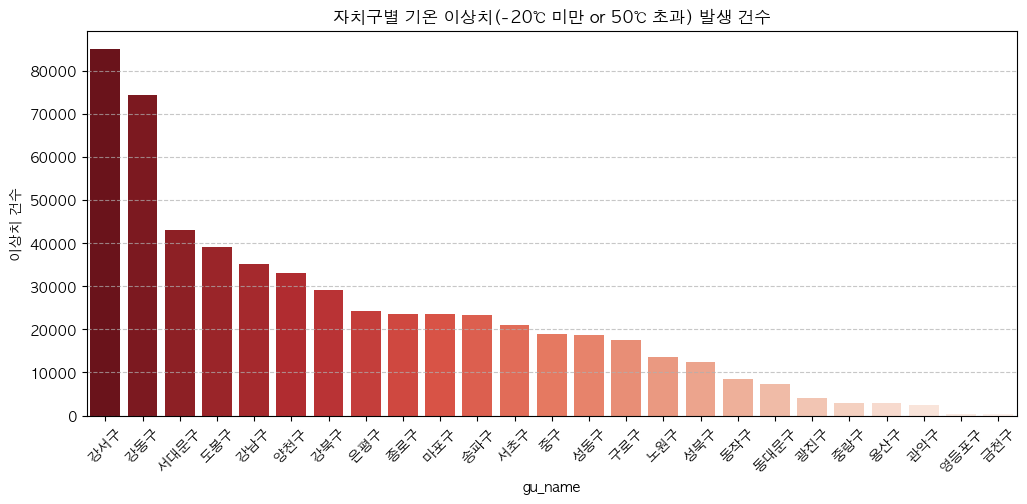

In [22]:
# 1. 전체 기온 이상치 데이터 건수 및 이상치를 뱉은 센서의 총 개수 파악
query_total_outliers = """
    SELECT 
        COUNT(*) as total_outlier_rows,
        COUNT(DISTINCT sensor_id) as total_outlier_sensors
    FROM v_sdot
    WHERE temp_avg < -20 OR temp_avg > 50
"""
outlier_stats = duckdb.sql(query_total_outliers).pl()
total_rows = outlier_stats['total_outlier_rows'][0]
total_sensors = outlier_stats['total_outlier_sensors'][0]

print(f"📊 총 기온 이상치 데이터: {total_rows:,}건")
# 전체 센서 개수
total_sensors_all = len(duckdb.sql('SELECT DISTINCT sensor_id FROM v_sdot').pl())
print(f"📊 이상치를 한 번이라도 내뿜은 센서: {total_sensors:,}개 / {total_sensors_all:,}개\n")

# 2. 이상치 발생 Top 15 센서 확인
query_outlier = """
    SELECT 
        gu_name,
        sensor_id,
        MIN(temp_avg) as min_temp,
        MAX(temp_avg) as max_temp,
        COUNT(*) as outlier_count
    FROM v_sdot
    WHERE temp_avg < -20 OR temp_avg > 50
    GROUP BY gu_name, sensor_id
    ORDER BY outlier_count DESC
    LIMIT 15
"""
df_outlier = duckdb.sql(query_outlier).pl()

print("🌋 [ 기온 이상치(-20도 미만 / 50도 초과) 발생 센서 Top 15 ]")
display(df_outlier)

# 3. 자치구별 이상치 발생 총 건수 시각화
query_outlier_gu = """
    SELECT gu_name, COUNT(*) as total_outliers
    FROM v_sdot
    WHERE temp_avg < -20 OR temp_avg > 50
    GROUP BY gu_name
    ORDER BY total_outliers DESC
"""
df_outlier_gu = duckdb.sql(query_outlier_gu).pl().to_pandas()

plt.figure(figsize=(12, 5))
sns.barplot(data=df_outlier_gu, x='gu_name', y='total_outliers', palette='Reds_r')
plt.title('자치구별 기온 이상치(-20℃ 미만 or 50℃ 초과) 발생 건수', fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('이상치 건수')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 센서 생존 기간 타임라인 시각화 (Gantt Chart)

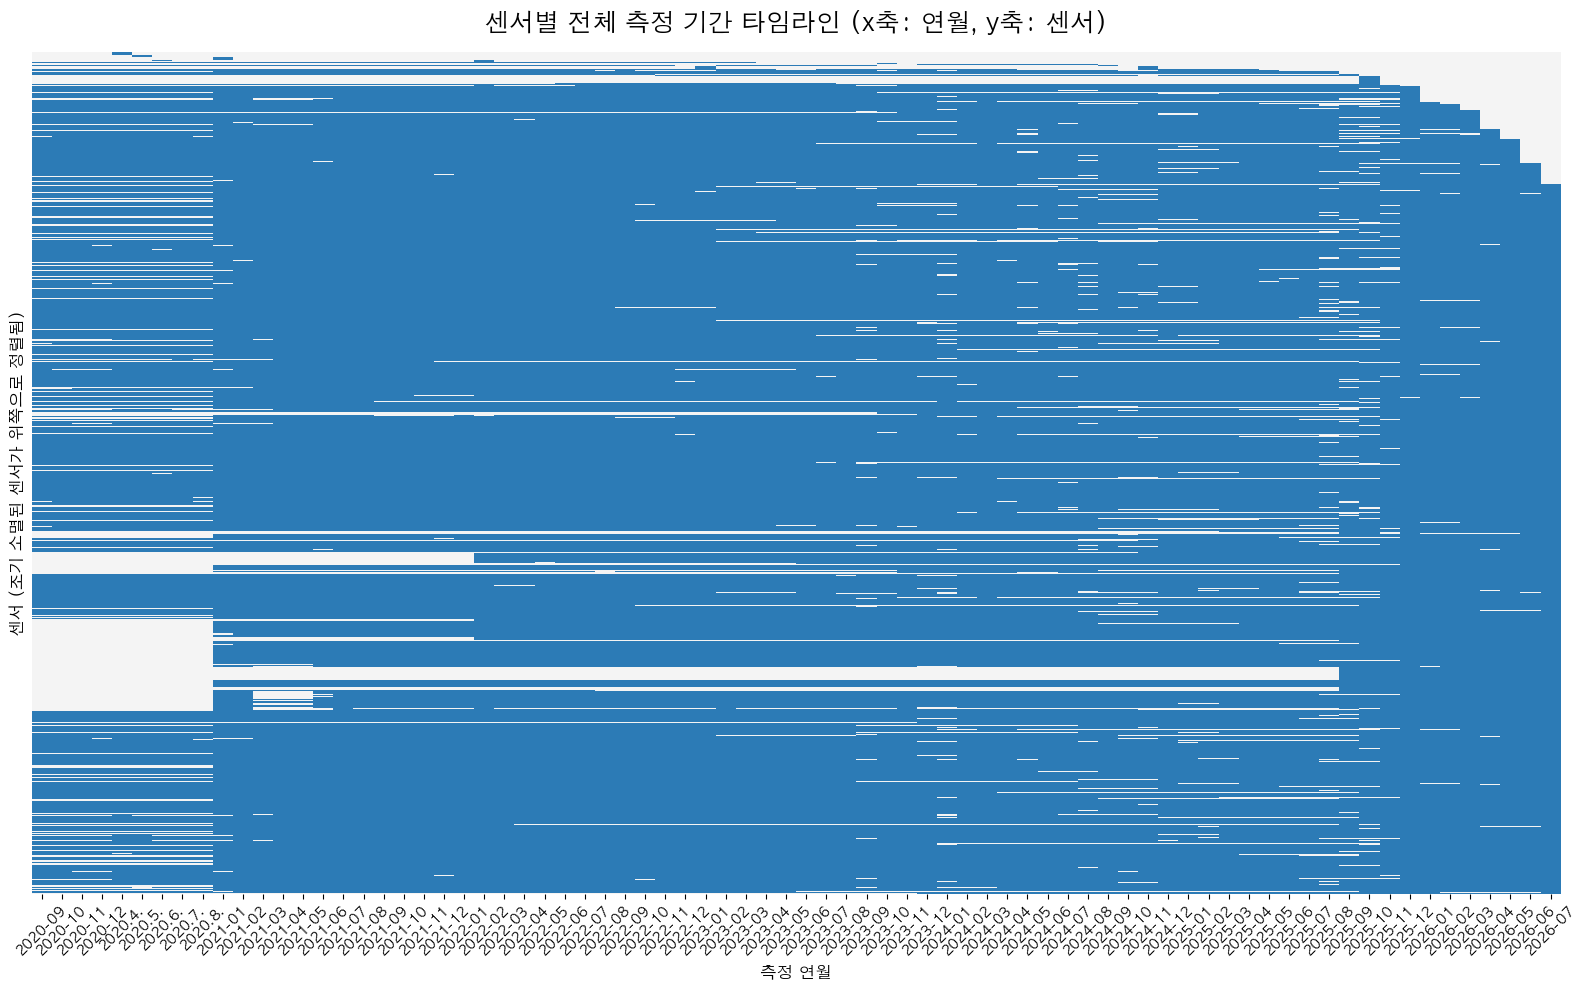

In [25]:
# --------------------------------------------------
# [5] 센서 생존 기간 및 결측 패턴 타임라인 시각화
# --------------------------------------------------
# 1. 월별 데이터 수집 건수 집계 (SUBSTRING을 이용해 'YYYY-MM'으로 초고속 압축)
query_timeline = """
    SELECT 
        sensor_id,
        SUBSTRING(measure_time, 1, 7) AS measure_month,
        COUNT(*) AS record_count
    FROM v_sdot
    GROUP BY sensor_id, measure_month
"""
df_timeline = duckdb.sql(query_timeline).df()

# 🚨 SUBSTRING으로 이미 'YYYY-MM' 형태를 만들었으므로 pandas의 datetime 변환 코드는 제거했습니다!

# 2. 피벗 테이블 생성 (Index: 센서, Columns: 연월, Values: 수집 건수)
pivot_timeline = df_timeline.pivot(index='sensor_id', columns='measure_month', values='record_count')

# 데이터 유무만 보기 위해 값이 있으면 1, 결측(NaN)이면 0으로 이진화
pivot_binary = pivot_timeline.notna().astype(int)

# 🚨 시각화를 위해 '가장 먼저 수집이 끊긴 센서' 순으로 정렬
# (마지막으로 1이 등장하는 컬럼 인덱스를 찾아 정렬)
last_active_month = pivot_binary.apply(lambda row: row.to_numpy().nonzero()[0][-1] if row.sum() > 0 else 0, axis=1)
pivot_binary_sorted = pivot_binary.iloc[last_active_month.argsort()]

# 3. 타임라인 히트맵 시각화
plt.figure(figsize=(16, 10))
sns.heatmap(
    pivot_binary_sorted, 
    cmap=['#f4f4f4', '#2c7bb6'],  # 0(결측)은 옅은 회색, 1(수집)은 파란색
    cbar=False, 
    yticklabels=False  # 센서 개수가 너무 많아 y축 라벨은 생략
)

plt.title("센서별 전체 측정 기간 타임라인 (x축: 연월, y축: 센서)", fontsize=18, pad=15)
plt.xlabel("측정 연월", fontsize=12)
plt.ylabel("센서 (조기 소멸된 센서가 위쪽으로 정렬됨)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 소멸 센서 개수

In [27]:
# [6] 센서 생존/소멸(측정 중단) 여부 집계 분석
query_dead_sensors = """
    WITH sensor_lifecycle AS (
        -- 1. 각 센서별 가장 마지막으로 데이터를 보낸 연월 추출
        SELECT 
            sensor_id,
            MAX(SUBSTRING(measure_time, 1, 7)) AS last_active_month
        FROM v_sdot
        GROUP BY sensor_id
    ),
    global_max AS (
        -- 2. 전체 데이터셋 기준 가장 최근 연월 (우측 끝 기준점)
        SELECT MAX(last_active_month) AS global_last_month
        FROM sensor_lifecycle
    )
    -- 3. 개별 센서의 마지막 연월과 글로벌 연월을 비교하여 소멸 여부 판별
    SELECT 
        CASE 
            WHEN s.last_active_month < g.global_last_month THEN '🔴 소멸 센서 (측정 영구 중단)'
            ELSE '🟢 활성 센서 (최근까지 생존)'
        END AS sensor_status,
        COUNT(*) AS sensor_count
    FROM sensor_lifecycle s
    CROSS JOIN global_max g
    GROUP BY sensor_status
    ORDER BY sensor_count DESC
"""
df_dead_status = duckdb.sql(query_dead_sensors).df()

print("📌 [ 전체 센서 생존 vs 소멸 집계 ]")
display(df_dead_status)

# (보너스) 소멸 센서들이 구체적으로 언제 가장 많이 죽었는지(대량 소멸 시기) 확인
query_dead_months = """
    WITH sensor_lifecycle AS (
        SELECT 
            sensor_id,
            MAX(SUBSTRING(measure_time, 1, 7)) AS last_active_month
        FROM v_sdot
        GROUP BY sensor_id
    ),
    global_max AS (
        SELECT MAX(last_active_month) AS global_last_month
        FROM sensor_lifecycle
    )
    SELECT 
        s.last_active_month AS 소멸_발생_연월,
        COUNT(*) AS 소멸_센서_수
    FROM sensor_lifecycle s
    CROSS JOIN global_max g
    WHERE s.last_active_month < g.global_last_month
    GROUP BY s.last_active_month
    ORDER BY 소멸_발생_연월 DESC
    LIMIT 10
"""
df_dead_months = duckdb.sql(query_dead_months).df()

📌 [ 전체 센서 생존 vs 소멸 집계 ]


,sensor_status,sensor_count
0,🟢 활성 센서 (최근까지 생존),1012
1,🔴 소멸 센서 (측정 영구 중단),188
